## Main notebook for generating all plots in the honors research distinction thesis

In [306]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics2 as IRSC

import VBMicrolensing
import MulensModel as mm
import os

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Figure 1

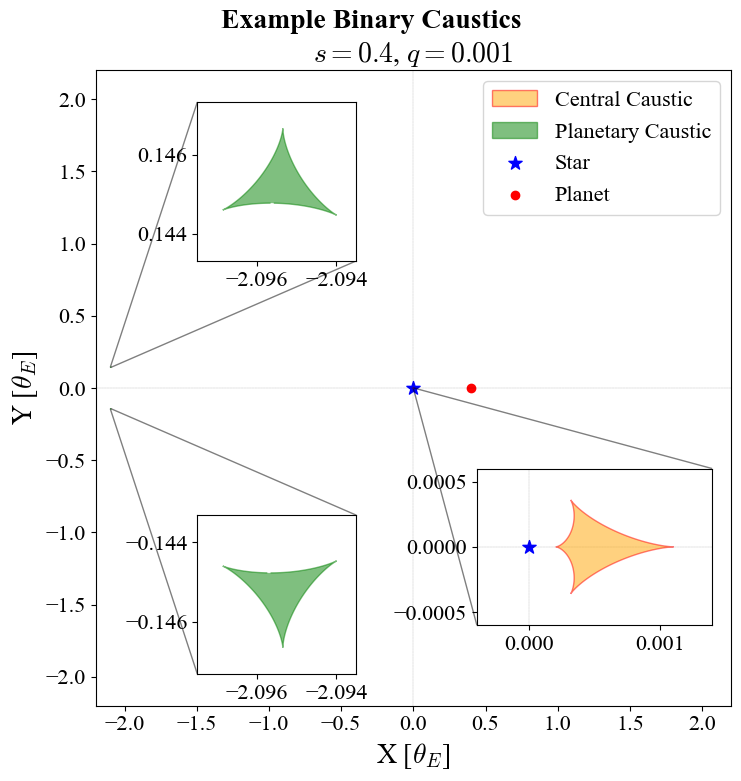

In [3]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = np.array([0, 0])

lens_attributes[:, :2] -= desired_offset

def plot_elements(target_ax, show_labels=False):
    x_c = caustics[2][0] + center_of_mass[0] - desired_offset[0]
    y_c = caustics[2][1] + center_of_mass[1] - desired_offset[1]
    points = np.array([x_c, y_c]).T
    kw = dict(label='Central Caustic') if show_labels else {}
    target_ax.add_patch(patches.Polygon(
        points, closed=False, fill=True,
        edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, **kw))

    for idx, i in enumerate([0, 1]):
        x_p = caustics[i][0] + center_of_mass[0] - desired_offset[0]
        y_p = caustics[i][1] + center_of_mass[1] - desired_offset[1]
        points = np.array([x_p, y_p]).T
        kw = dict(label='Planetary Caustic') if (show_labels and idx == 0) else {}
        target_ax.add_patch(patches.Polygon(
            points, closed=False, fill=True,
            edgecolor='green', facecolor='green', alpha=0.5, zorder=5, **kw))

    kw_s = dict(label='Star') if show_labels else {}
    kw_p = dict(label='Planet') if show_labels else {}
    target_ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
                      color='blue', s=100, marker='*', **kw_s)
    target_ax.scatter(lens_attributes[1, 0], lens_attributes[1, 1],
                      color='red', marker='o', **kw_p)

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Example Binary Caustics', y=0.97)

plot_elements(ax, show_labels=True)

ax.set_aspect('equal')

view = 2.2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(loc='upper right')

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.6, 0.1, 0.37, 0.3])
plot_elements(axins1)
axins1.set_xlim(-0.0004, 0.0014)
axins1.set_ylim(-0.0006, 0.0006)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='black')

# Inset 2: Upper planetary caustic [-1.05, -0.95] x [0.1, 0.15]
axins2 = ax.inset_axes([0.1, 0.7, 0.37, 0.25])
plot_elements(axins2)
middle_caustic_x = np.average(caustics[1][0]) + 0.0003
middle_caustic_y = np.average(caustics[1][1])
axins2.set_xlim(middle_caustic_x - 0.002, middle_caustic_x + 0.002)
axins2.set_ylim(middle_caustic_y - 0.002, middle_caustic_y + 0.002)
axins2.set_aspect('equal')
axins2.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins2.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins2, edgecolor='black')

# Inset 3: Lower planetary caustic [-1.05, -0.95] x [-0.15, -0.1]
axins3 = ax.inset_axes([0.1, 0.05, 0.37, 0.25])
plot_elements(axins3)
middle_caustic_x = np.average(caustics[0][0]) + 0.0003
middle_caustic_y = np.average(caustics[0][1])
axins3.set_xlim(middle_caustic_x - 0.002, middle_caustic_x + 0.002)
axins3.set_ylim(middle_caustic_y - 0.002, middle_caustic_y + 0.002)
axins3.set_aspect('equal')
axins3.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins3.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins3, edgecolor='black')

# fig.savefig('./Figures/Binary Caustic Example.png', dpi=300)

plt.show()

### Figure 2

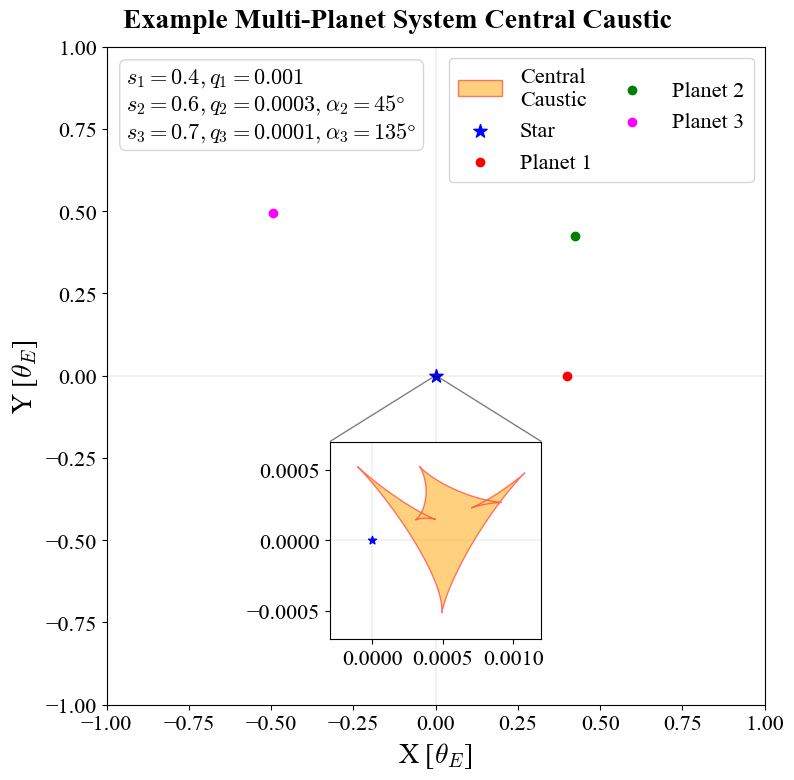

In [4]:
s1 = 0.4
q1 = 1e-3
alpha1 = 0
s2 = 0.6
q2 = 3e-4
alpha2 = 45
s3 = 0.7
q3 = 1e-4
alpha3 = 135

lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2],
    [s3*np.cos(np.deg2rad(alpha3)), s3*np.sin(np.deg2rad(alpha3)), q3]
])

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
desired_offset = center_of_mass

# lens_attributes[:, :2] -= desired_offset
lens_attributes[:, :2] -= np.array([0, 0])

VBM.SetLensGeometry(lens_attributes.flatten().tolist())
caustics = VBM.Multicaustics()
caustics = np.array(caustics, dtype=object)

def plot_elements(target_ax, show_labels=False):
    x_c = caustics[0][0] + center_of_mass[0] - desired_offset[0]
    y_c = caustics[0][1] + center_of_mass[1] - desired_offset[1]
    points = np.array([x_c, y_c]).T
    kw = dict(label='Central Caustic') if show_labels else {}
    target_ax.add_patch(patches.Polygon(
        points, closed=False, fill=True,
        edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, **kw))

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Example Multi-Planet System Central Caustic', y=0.97)

x_c = caustics[5][0] + center_of_mass[0] - desired_offset[0]
y_c = caustics[5][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x_c, y_c]).T

ax.add_patch(patches.Polygon(
    points, closed=False, fill=True,
    edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, label='Central\nCaustic'))

ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star', s=100)

colors = ['blue', 'red', 'green', 'magenta', 'cyan']

for i in range(1, len(lens_attributes)):
    ax.scatter(lens_attributes[i, 0], lens_attributes[i, 1], marker='o', color=colors[i], label=f'Planet {i}')

ax.set_aspect('equal')
view = 1
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.3, 0.1, 0.4, 0.3])
axins1.add_patch(patches.Polygon(
    points, closed=False, fill=True,
    edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, label='Central\nCaustic'))
axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star')
axins1.set_xlim(-0.0003, 0.0012)
axins1.set_ylim(-0.0007, 0.0007)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='black')

ax.legend(ncol=2, loc='upper right', columnspacing=0.8)

text_str = '\n'.join([
    f'$s_1 = {s1}, q_1 = {q1}$',
    f'$s_2 = {s2}, q_2 = {q2}, \\alpha_2 = {alpha2} \\degree$',
    f'$s_3 = {s3}, q_3 = {q3}, \\alpha_3 = {alpha3} \\degree$'
])

ax.text(0.03, 0.97, text_str, transform=ax.transAxes,
        fontsize=16, ha='left', va='top', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round', edgecolor='0.8'))

# fig.savefig('./Figures/Multi-Planet Caustic Example.png', dpi=300)

plt.show()

### Figure 3

Testing different offsets for a sample triple lens system

In [5]:
s1 = 0.4
q1 = 1e-3
alpha1 = 0
s2 = 0.6
q2 = 3e-4
alpha2 = 45
s3 = 0.7
q3 = 1e-4
alpha3 = 135

lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2],
    [s3*np.cos(np.deg2rad(alpha3)), s3*np.sin(np.deg2rad(alpha3)), q3]
])

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
desired_offset = center_of_mass

# lens_attributes[:, :2] -= desired_offset
lens_attributes[:, :2] -= np.array([0, 0])

VBM.SetLensGeometry(lens_attributes.flatten().tolist())
caustics = VBM.Multicaustics()
caustics = np.array(caustics, dtype=object)

## Determining width of map

#### Locations of cusps

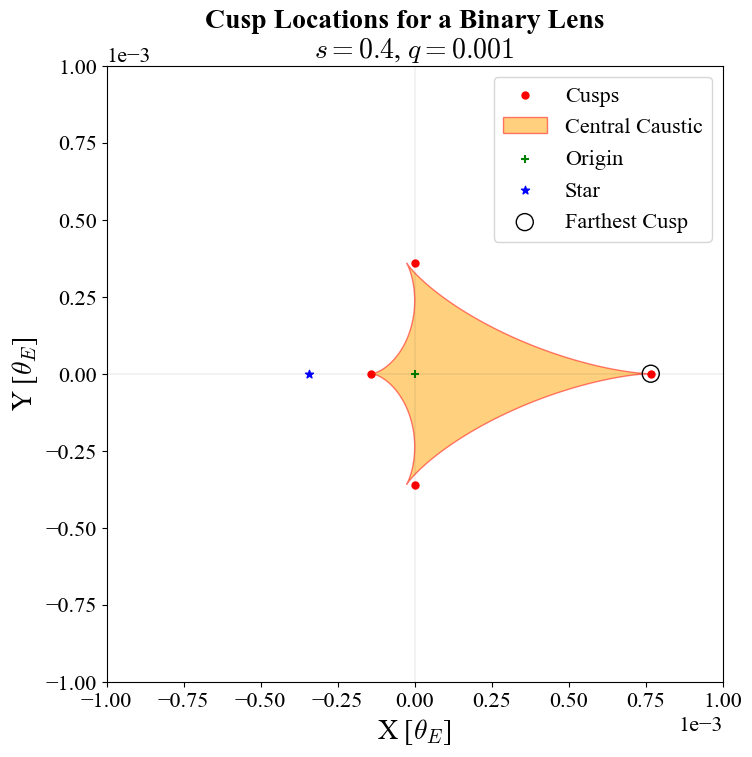

In [237]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=desired_offset)

lens_attributes[:, :2] -= desired_offset

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Cusp Locations for a Binary Lens', y=0.95)

for caustic_points in cusp_points:
    ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps', s=100)

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
ax.add_patch(fpr)

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')
ax.scatter(caustic_points[1, 0], caustic_points[1, 1], color='black', marker='o', label='Farthest Cusp', s=150, facecolor='none')

ax.set_aspect('equal')

view = 0.001
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

ax.legend()

# fig.savefig('./Figures/Cusp Locations for a Binary Lens.png', dpi=300)

plt.show()

Extent of magnification map

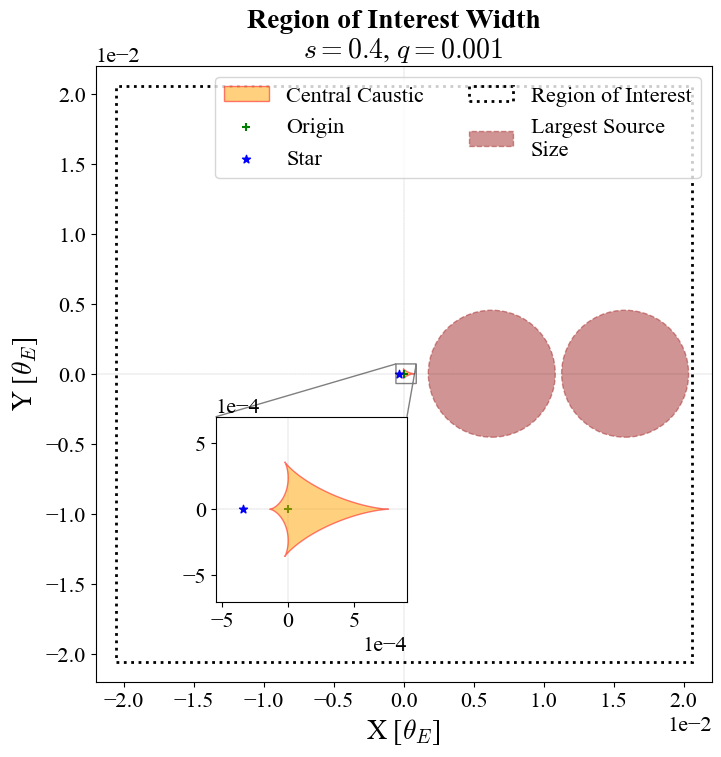

In [ ]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=desired_offset)

lens_attributes[:, :2] -= desired_offset

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Region of Interest Width', y=0.95)

# for caustic_points in cusp_points:
#     ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps', s=100)

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
ax.add_patch(fpr)

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', linewidth=2, label='Region of Interest')
large_source_patch_1 = patches.Circle((ang_width/2 - 1.05*max_source_radius, 0), radius=max_source_radius, facecolor='brown', edgecolor='brown', linestyle='--', alpha=0.5, label='Largest Source\nSize')
large_source_patch_2 = patches.Circle((ang_width/2 - 3.15*max_source_radius, 0), radius=max_source_radius, facecolor='brown', edgecolor='brown', linestyle='--', alpha=0.5)

ax.add_patch(map_patch)
ax.add_patch(large_source_patch_1)
ax.add_patch(large_source_patch_2)

ax.set_aspect('equal')

view = 0.022
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.15, 0.13, 0.4, 0.3])
axins1.add_patch(patches.Polygon(
    points, closed=False, fill=True,
    edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, label='Central\nCaustic'))
axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star')
axins1.scatter(0, 0,
          color='green', marker='+', label='Origin')
axins1.set_xlim(-0.00055, 0.0009)
axins1.set_ylim(-0.0007, 0.0007)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='black')

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
axins1.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

ax.legend(ncol=2)

# fig.savefig('./Figures/Region of Interest Width.png', dpi=300)

plt.show()

Source ring

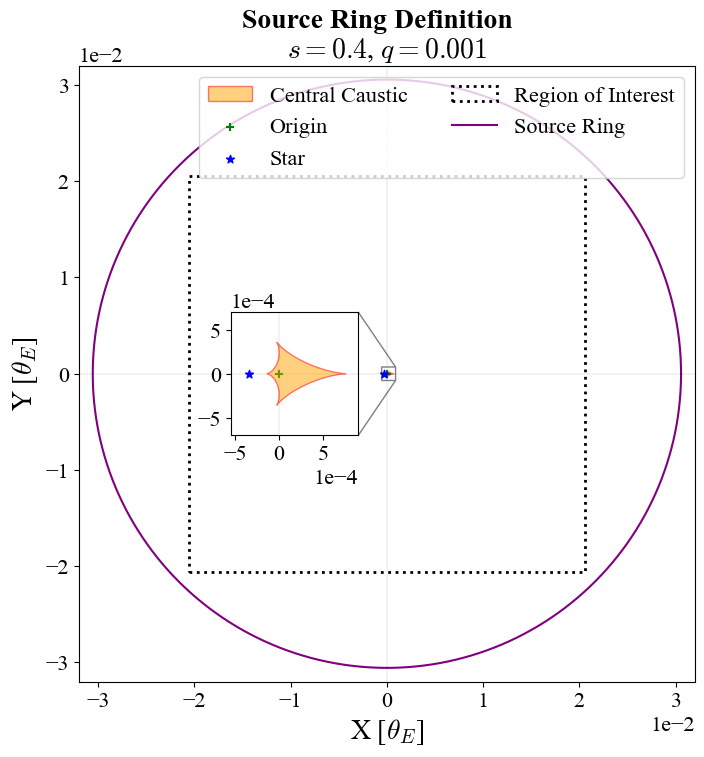

In [ ]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=desired_offset)

lens_attributes[:, :2] -= desired_offset

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Source Ring Definition', y=0.95)

# for caustic_points in cusp_points:
#     ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps', s=100)

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
ax.add_patch(fpr)

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', linewidth=2, label='Region of Interest')
ax.add_patch(map_patch)

u = 1.05 * ang_width / np.sqrt(2)

# Defining ring slightly larger than magnification map extent
thetas = np.linspace(0, 2*np.pi, 10000, endpoint=True)
xs = u * np.cos(thetas)
ys = u * np.sin(thetas)

ax.plot(xs, ys, color='purple', label='Source Ring')

ax.set_aspect('equal')

view = 0.032
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.2, 0.4, 0.3, 0.2])
axins1.add_patch(patches.Polygon(
    points, closed=False, fill=True,
    edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, label='Central\nCaustic'))
axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star')
axins1.scatter(0, 0,
          color='green', marker='+', label='Origin')
axins1.set_xlim(-0.00055, 0.0009)
axins1.set_ylim(-0.0007, 0.0007)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='black')
axins1.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

ax.legend(ncol=2, loc='upper right')

# fig.savefig('./Figures/Source Ring Definition.png', dpi=300)

plt.show()

Critical curves

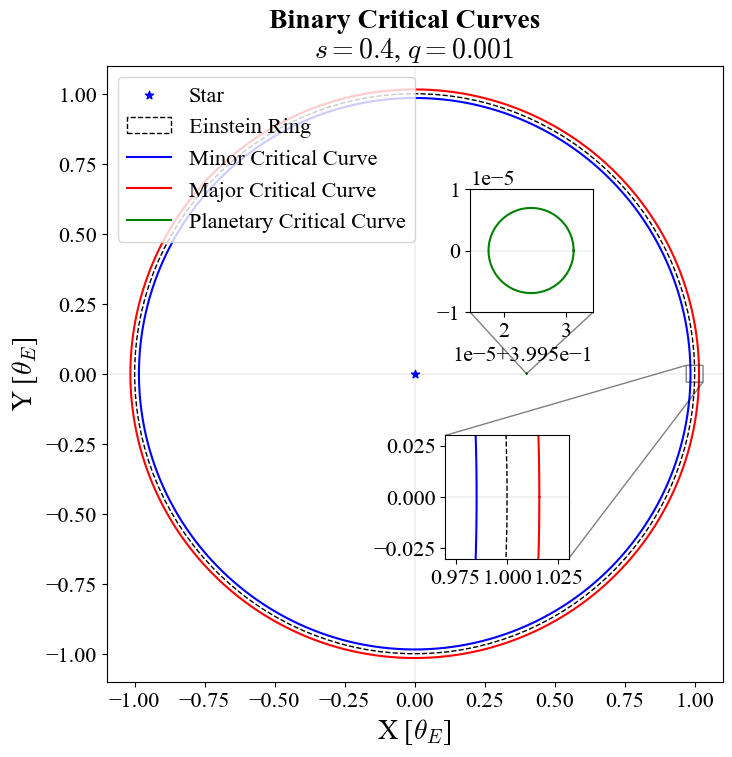

In [ ]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=desired_offset)

lens_attributes[:, :2] -= desired_offset

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Binary Critical Curves', y=0.95)

# fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
# ax.add_patch(fpr)

# ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

u = 1.05 * ang_width / np.sqrt(2)

# Defining ring slightly larger than magnification map extent
thetas = np.linspace(0, 2*np.pi, 10000, endpoint=True)
xs = u * np.cos(thetas)
ys = u * np.sin(thetas)

model = IRSF.IRSFunctions._MyBinaryLens(q=q, s=s)
all_points = []
ring_magnifications = []

for x, y in zip(xs, ys):
    magnification, image_positions = model.get_n_images(x - center_of_mass[0], y - center_of_mass[1])

    for image_position in image_positions:
        all_points.append([image_position.real, image_position.imag])

    ring_magnifications.append(magnification)

all_points = np.array(all_points)
ring_magnifications = np.array(ring_magnifications)

offset_circle, small_circle, large_circle = IRSF.IRSFunctions._separate_circles(all_points, q, s)

ax.plot(small_circle[:, 0], small_circle[:, 1], color='b', linestyle='-', label='Minor Critical Curve')
ax.plot(large_circle[:, 0], large_circle[:, 1], color='r', linestyle='-', label='Major Critical Curve')
ax.plot(offset_circle[:, 0], offset_circle[:, 1], color='g', linestyle='-', label='Planetary Critical Curve')

view = 1.1
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)
ax.set_aspect('equal')

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
ax.legend(loc='upper left')

# Inset 2
axins2 = ax.inset_axes([0.59, 0.6, 0.2, 0.2])
plot_elements(axins2)
offset = 0.00001
center = np.average(offset_circle[:, 0])
axins2.set_xlim(center - offset, center + offset)
axins2.set_ylim(-offset, offset)
axins2.plot(small_circle[:, 0], small_circle[:, 1], color='b', linestyle='-', label='Minor Critical Curve')
axins2.plot(large_circle[:, 0], large_circle[:, 1], color='r', linestyle='-', label='Major Critical Curve')
axins2.plot(offset_circle[:, 0], offset_circle[:, 1], color='g', linestyle='-', label='Planetary Critical Curve')
ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
axins2.add_patch(ring_patch)
axins2.set_aspect('equal')
axins2.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins2.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins2, edgecolor='black')

# Inset 3
axins3 = ax.inset_axes([0.55, 0.2, 0.2, 0.2])
axins3.set_xlim(0.97, 1.03)
axins3.set_ylim(-0.03, 0.03)
axins3.plot(small_circle[:, 0], small_circle[:, 1], color='b', linestyle='-', label='Minor Critical Curve')
axins3.plot(large_circle[:, 0], large_circle[:, 1], color='r', linestyle='-', label='Major Critical Curve')
axins3.plot(offset_circle[:, 0], offset_circle[:, 1], color='g', linestyle='-', label='Planetary Critical Curve')
ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
axins3.add_patch(ring_patch)
axins3.set_aspect('equal')
axins3.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins3.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins3, edgecolor='black')

# fig.savefig('./Figures/Binary Critical Curves.png', dpi=300)

plt.show()

Small sources

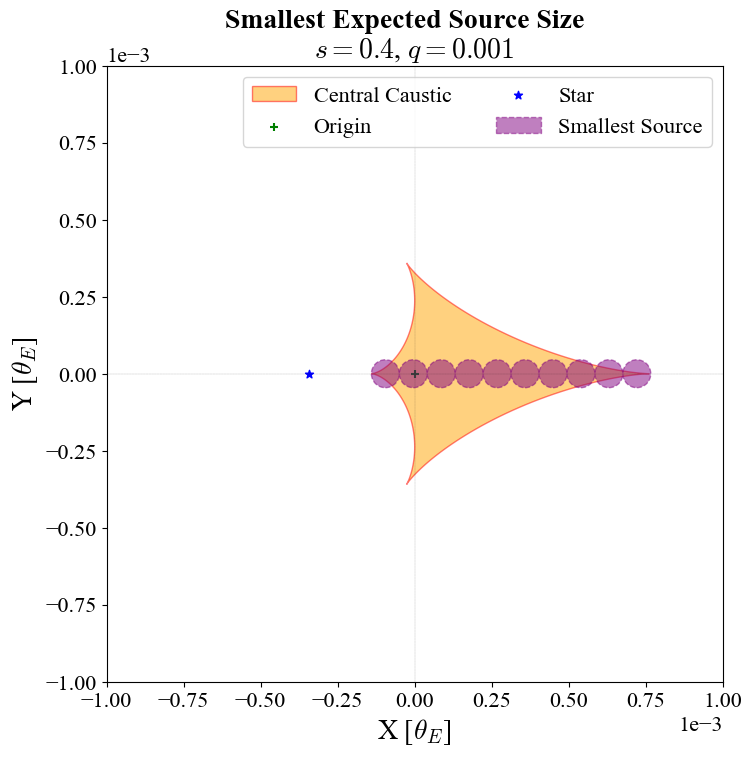

In [181]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=desired_offset)

lens_attributes[:, :2] -= desired_offset

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Smallest Expected Source Size', y=0.95)

# for caustic_points in cusp_points:
#     ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps', s=100)

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
ax.add_patch(fpr)

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

for i in range(10):
    if i == 0:
        small_source_patch = patches.Circle((cusp_points[0, 0, 0] + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5, label='Smallest Source')
    else:
        small_source_patch = patches.Circle((cusp_points[0, 0, 0] + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5)
    ax.add_patch(small_source_patch)

ax.set_aspect('equal')

view = 0.001
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

ax.legend(ncol=2)

# fig.savefig('./Figures/Smallest Expected Source Size.png', dpi=300)

plt.show()

Pixelating

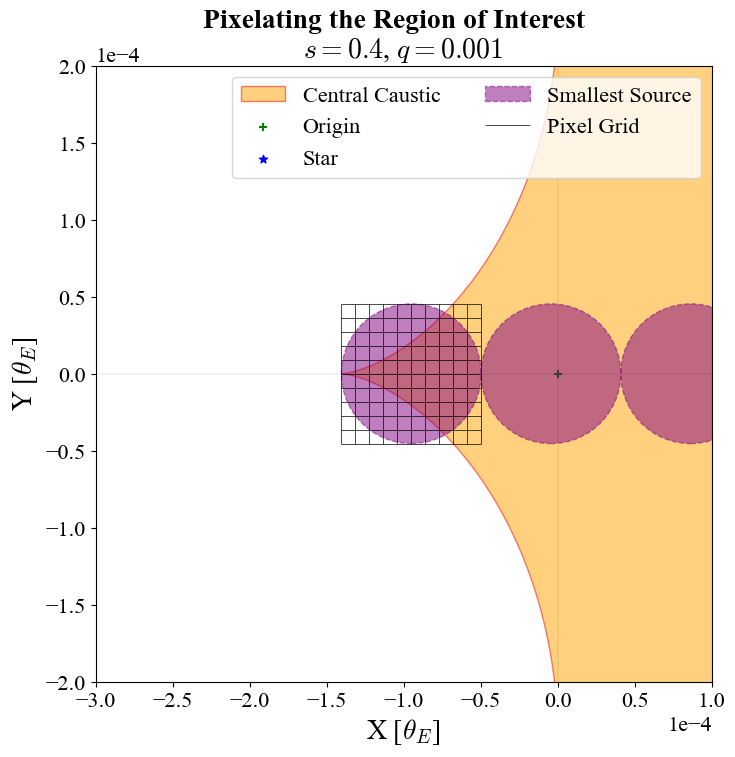

In [ ]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=desired_offset)

lens_attributes[:, :2] -= desired_offset

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Pixelating the Region of Interest', y=0.95)

# for caustic_points in cusp_points:
#     ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps', s=100)

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
ax.add_patch(fpr)

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

for i in range(10):
    if i == 0:
        small_source_patch = patches.Circle((cusp_points[0, 0, 0] + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5, label='Smallest Source')
    else:
        small_source_patch = patches.Circle((cusp_points[0, 0, 0] + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5)
    ax.add_patch(small_source_patch)

xs = np.linspace(cusp_points[0, 0, 0], cusp_points[0, 0, 0] + 2*min_source_radius, 11)
ys = np.linspace(-min_source_radius, min_source_radius, 11)

ax.hlines(ys, cusp_points[0, 0, 0], cusp_points[0, 0, 0] + 2*min_source_radius, colors='black', linestyles='-', linewidth=0.5, alpha=1)
ax.vlines(xs, -min_source_radius, min_source_radius, colors='black', linestyles='-', linewidth=0.5, alpha=1, label='Pixel Grid')

ax.set_aspect('equal')

view = 0.0002
offset = -0.0001
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view + offset, view + offset, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

ax.legend(ncol=2)

# fig.savefig('./Figures/Pixelating the Region of Interest.png', dpi=300)

plt.show()

In [224]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

lens_attributes[:, :2] -= desired_offset

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=desired_offset)

pixels = 4691
delta = 0.2

(y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs=qs, ss=ss)
num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=delta, r_theta_ratio=4)

print(f'Pixels: {pixels}')
print(f'Angular width: {ang_width}')
print(f'Minimum magnification: {min_mag}')
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, thickness = {y_plus - y_minus}')
print(f'Average radius of annulus: {(y_plus + y_minus)/2}')
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')
print(f'Maximum source radius: {max_source_radius}')
print(f'Minimum source radius: {min_source_radius}')

triple_lens_parameters_1 = {
    'lens_att': lens_attributes.tolist(),
    'pixels': pixels,
    'ang_width': 3.5 * ang_width / 2,
    'num_r': num_r,
    'num_theta': num_theta,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'thickness': y_plus - y_minus
}

sim_big = IRSC.IRSCaustics(annulus_param_dict=triple_lens_parameters_1)
magnifications_big = sim_big.series_calculate(cm_offset='auto', annulus_offset=desired_offset)

Pixels: 4691
Angular width: 0.04116175012726738
Minimum magnification: 32.03574863849047
Annulus bounds: y+ = 1.0153947372236505, y- = 0.9848389560659494, thickness = 0.03055578115770108
Average radius of annulus: 1.0001168466447998
Number of rays: num_r = 88212, num_theta = 22053
Total number of rays: 1.945e+09
Maximum source radius: 0.00453514739229025
Minimum source radius: 4.53514739229025e-05


100%|██████████| 2206/2206 [00:36<00:00, 60.07it/s]


---------------------
Total time: 36.816 seconds


/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_67542/375684708.py:7: RuntimeWarning: divide by zero encountered in log10
  plot = ax.imshow(np.log10(magnifications_big), cmap='gray', extent=[-sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2, -sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2])
/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_67542/375684708.py:45: RuntimeWarning: divide by zero encountered in log10
  axins1.imshow(np.log10(magnifications_big), cmap='gray', extent=[-sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2, -sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2])


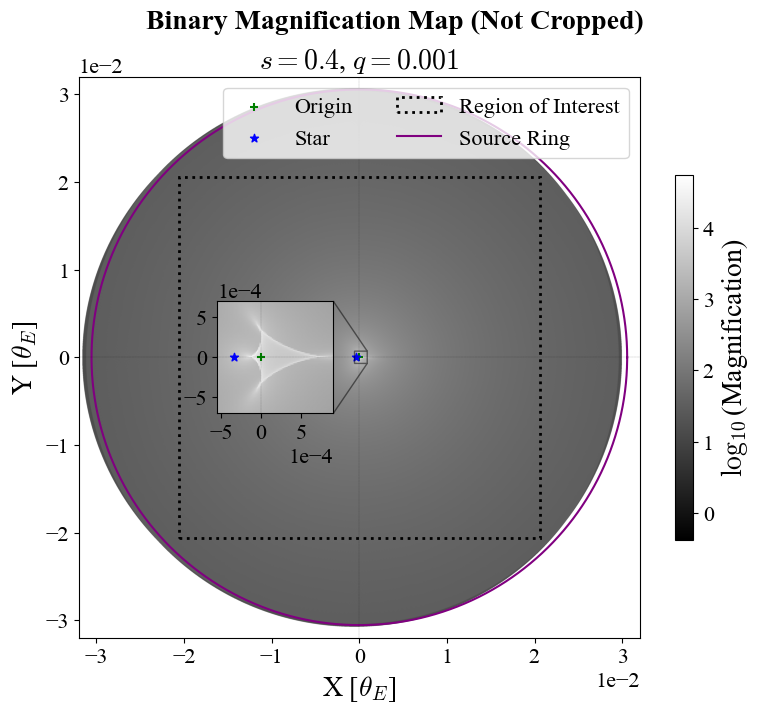

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Binary Magnification Map (Not Cropped)', y=0.91)

plot = ax.imshow(np.log10(magnifications_big), cmap='gray', extent=[-sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2, -sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2])
bar = plt.colorbar(plot, shrink=0.5)
bar.set_label(r'$\log_{10}$(Magnification)')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', linewidth=2, label='Region of Interest')
ax.add_patch(map_patch)

u = 1.05 * ang_width / np.sqrt(2)

# Defining ring slightly larger than magnification map extent
thetas = np.linspace(0, 2*np.pi, 10000, endpoint=True)
xs = u * np.cos(thetas)
ys = u * np.sin(thetas)

ax.plot(xs, ys, color='purple', label='Source Ring')

ax.set_aspect('equal')

view = 0.032
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.2, 0.4, 0.3, 0.2])
# axins1.add_patch(patches.Polygon(
#     points, closed=False, fill=True,
#     edgecolor='red', facecolor='orange', alpha=0.2, zorder=5, label='Central\nCaustic'))
axins1.imshow(np.log10(magnifications_big), cmap='gray', extent=[-sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2, -sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2])
axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star')
axins1.scatter(0, 0,
          color='green', marker='+', label='Origin')
axins1.set_xlim(-0.00055, 0.0009)
axins1.set_ylim(-0.0007, 0.0007)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='black')
axins1.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

ax.legend(ncol=2, loc='upper right')

# fig.savefig('./Figures/Binary Magnification Map (Not Cropped).png', dpi=300)

plt.show()

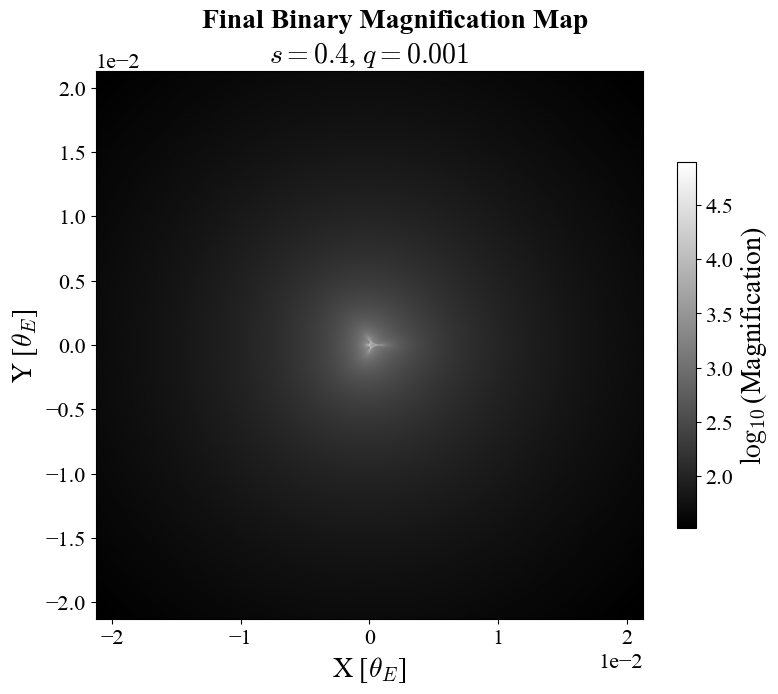

In [253]:
s = 0.4
q = 1e-3

sim = IRSC.caustic_reader(f'../../Unity/Simulations/Binary_Collection/Binary_Collection_{q:.0e}/binary_{q:.0e}_{s:.2e}.pkl')
magnifications = sim.magnifications

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Final Binary Magnification Map', y=0.895)

plot = ax.imshow(np.log10(magnifications), cmap='gray', extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2])
bar = plt.colorbar(plot, shrink=0.5)
bar.set_label(r'$\log_{10}$(Magnification)')

# ax.scatter(0, 0, color='green', marker='+', label='Origin')
# ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

# ax.add_patch(patches.Polygon(
#     points, closed=False, fill=True,
#     edgecolor='red', facecolor='orange', alpha=0.2, zorder=5, label='Central\nCaustic'))
# map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', linewidth=2, label='Region of Interest')
# ax.add_patch(map_patch)

ax.set_aspect('equal')

view = sim.ang_width/2 + sim.ang_res/2
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

# ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
# ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
# axins1 = ax.inset_axes([0.2, 0.4, 0.3, 0.2])
# axins1.add_patch(patches.Polygon(
#     points, closed=False, fill=True,
#     edgecolor='red', facecolor='orange', alpha=0.2, zorder=5, label='Central\nCaustic'))
# axins1.imshow(np.log10(magnifications), cmap='gray', extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2])
# axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
#           color='blue', marker='*', label='Star')
# axins1.scatter(0, 0,
#           color='green', marker='+', label='Origin')
# axins1.set_xlim(-0.00055, 0.0009)
# axins1.set_ylim(-0.0007, 0.0007)
# axins1.set_aspect('equal')
# axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
# axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
# ax.indicate_inset_zoom(axins1, edgecolor='black')
# axins1.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# ax.legend(ncol=2, loc='upper right')

# fig.savefig('./Figures/Final Binary Magnification Map.png', dpi=300)

plt.show()

100%|██████████| 100/100 [00:00<00:00, 5489.71it/s]
/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_67542/1823614151.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig('./Figures/Limb-Darkened Source Profiles.png', dpi=300)
/Users/saividyud/Documents/GitHub/NBLens/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


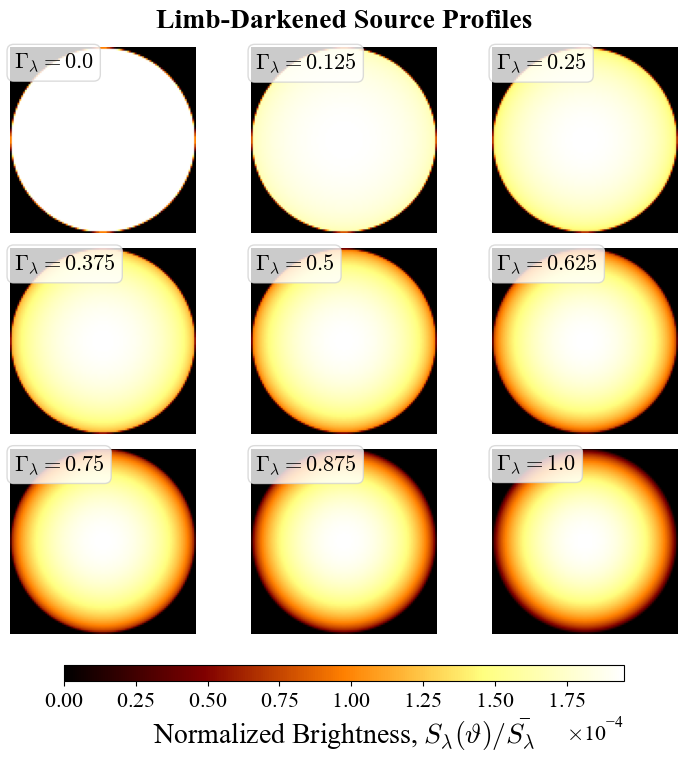

In [333]:
# Discretizing limb-darkening coefficient
LD_coeffs = np.linspace(0, 1, 9)

rad = max_source_radius/10

source_profiles = []

for i, LD_coeff in enumerate(LD_coeffs):
    source_profile = IRSF.IRSFunctions.source_profile(sim.ang_res, rad=rad, profile_type='LD', LD=LD_coeff)
    source_profiles.append(source_profile)

fig = plt.figure()
fig.set_tight_layout({'rect': [0, 0.14, 1, 0.96]})
axes = fig.subplots(3, 3)

fig.suptitle('Limb-Darkened Source Profiles', y=0.94)

for i, source_profile in enumerate(source_profiles):
    ax = axes[i // 3, i % 3]
    
    plot = ax.imshow(source_profile, cmap='afmhot', extent=[-rad - sim.ang_res/2, rad + sim.ang_res/2, -rad - sim.ang_res/2, rad + sim.ang_res/2])
    ax.axis('off')

    props = dict(boxstyle='round', facecolor='white', edgecolor='lightgray', alpha=0.8)
    ax.text(0.02, 0.98, f'$\Gamma_\lambda = {LD_coeffs[i]}$', va='top', zorder=10, bbox=props, transform=ax.transAxes, fontsize=16)

cbar_ax = fig.add_axes([0.15, 0.1, 0.7, 0.02])
bar = fig.colorbar(plot, cax=cbar_ax, orientation='horizontal')
bar.ax.ticklabel_format(style='scientific', scilimits=(0, 0), useMathText=True)
bar.set_label(r'Normalized Brightness, $S_\lambda(\vartheta)/\bar{S_\lambda}$')

fig.savefig('./Figures/Limb-Darkened Source Profiles.png', dpi=300)

plt.show()

100%|██████████| 100/100 [00:00<00:00, 4583.84it/s]


Convolving source profile with magnification map: 1.005 seconds


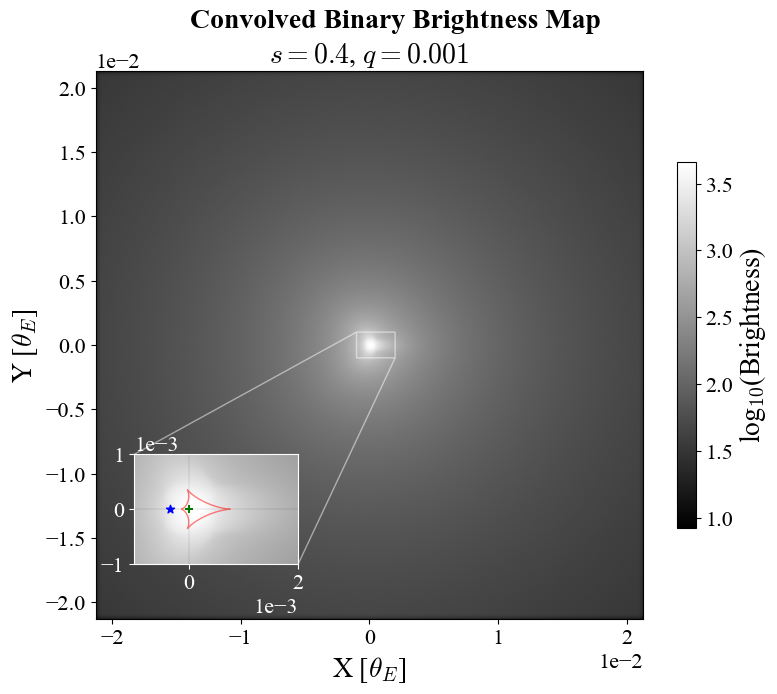

In [393]:
LD_coeff = 0.5
rad = max_source_radius/10

source_profile = IRSF.IRSFunctions.source_profile(sim.ang_res, rad=rad, profile_type='LD', LD=LD_coeff)
brightnesses = sim.convolve(source_profile)

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Convolved Binary Brightness Map', y=0.895)

plot = ax.imshow(np.log10(brightnesses), cmap='gray', extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2])
bar = plt.colorbar(plot, shrink=0.5)
bar.set_label(r'log$_{10}$(Brightness)')

# ax.scatter(0, 0, color='green', marker='+', label='Origin')
# ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

# ax.add_patch(patches.Polygon(
#     points, closed=False, fill=True,
#     edgecolor='red', facecolor='orange', alpha=0.2, zorder=5, label='Central\nCaustic'))
# map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', linewidth=2, label='Region of Interest')
# ax.add_patch(map_patch)

ax.set_aspect('equal')

view = sim.ang_width/2 + sim.ang_res/2
offset = 0
ax.set_xlim(-view+offset, view+offset)
ax.set_ylim(-view, view)

# ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
# ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.07, 0.1, 0.3, 0.2])
axins1.add_patch(patches.Polygon(
    points, closed=False, fill=True,
    edgecolor='red', facecolor='none', alpha=0.5, zorder=5, label='Central\nCaustic'))
axins1.imshow(np.log10(brightnesses), cmap='gray', extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2])
axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star')
axins1.scatter(0, 0,
          color='green', marker='+', label='Origin')
axins1.set_xlim(-0.001, 0.002)
axins1.set_ylim(-0.001, 0.001)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='white')
axins1.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# Change axins1 axes ticks to white color
axins1.tick_params(colors='white')
# Add white boundary to axins1
axins1.spines['bottom'].set_color('white')
axins1.spines['left'].set_color('white')
axins1.spines['right'].set_color('white')
axins1.spines['top'].set_color('white')

# Make axes ticks in scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
bar.ax.ticklabel_format(style='scientific', scilimits=(0, 0))

# axins1.legend(ncol=2, loc='upper right', transform=ax.transAxes)

# fig.savefig('./Figures/Convolved Binary Brightness Map.png', dpi=300)

plt.show()

In [386]:
s = 0.4
q = 1e-3

sim_single = IRSC.caustic_reader(f'../../Unity/Simulations/Single_Collection/Single_Collection_{q:.0e}/single_{q:.0e}_{s:.2e}.pkl')
sim_binary = IRSC.caustic_reader(f'../../Unity/Simulations/Binary_Collection/Binary_Collection_{q:.0e}/binary_{q:.0e}_{s:.2e}.pkl')
magnifications_single = sim_single.magnifications
magnifications_binary = sim_binary.magnifications

brightnesses_single = sim_single.convolve(source_profile)
brightnesses_binary = sim_binary.convolve(source_profile)

fractional_difference = (brightnesses_binary - brightnesses_single) / brightnesses_single

Convolving source profile with magnification map: 1.775 seconds
Convolving source profile with magnification map: 0.981 seconds


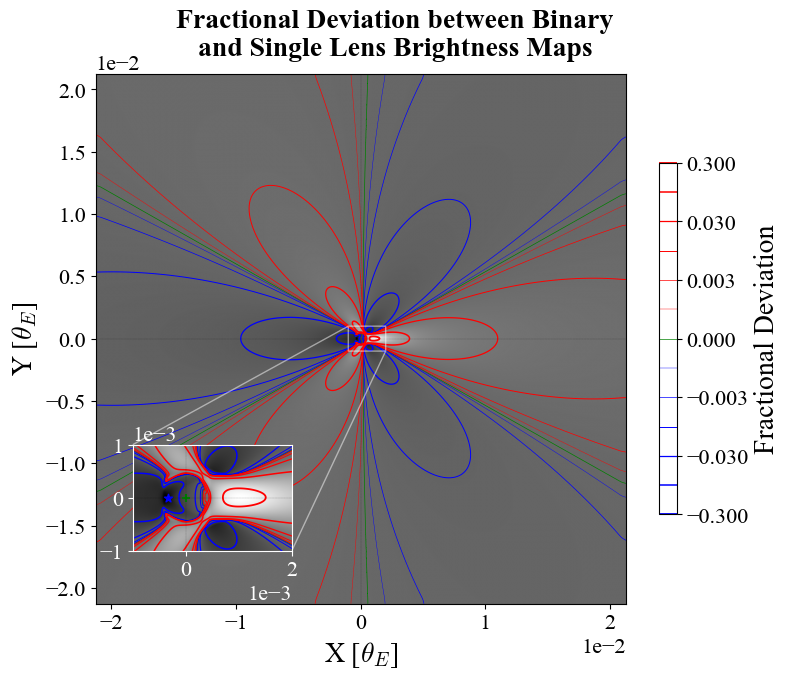

In [394]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Fractional Deviation between Binary\nand Single Lens Brightness Maps', y=0.87)

plot = ax.imshow(fractional_difference, 
                 cmap='gray',
                 extent=[-sim_binary.ang_width/2 - sim_binary.ang_res/2, sim_binary.ang_width/2 + sim_binary.ang_res/2, -sim_binary.ang_width/2 - sim_binary.ang_res/2, sim_binary.ang_width/2 + sim_binary.ang_res/2],
)
plot = ax.contour(fractional_difference,
           levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'green', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.5, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim_binary.ang_width/2, sim_binary.ang_width/2, -sim_binary.ang_width/2, sim_binary.ang_width/2]
)

bar = plt.colorbar(plot, shrink=0.5)
bar.set_label('Fractional Deviation')

# ax.set_title(f'$s$ = {s}, $q$ = {q}\n$\\rho$ = {rad:.3e} $\\theta_E$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

view = sim_binary.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Inset view
axins1 = ax.inset_axes([0.07, 0.1, 0.3, 0.2])
# axins1.add_patch(patches.Polygon(
#     points, closed=False, fill=True,
#     edgecolor='red', facecolor='none', alpha=0.5, zorder=5, label='Central\nCaustic'))
plot = axins1.imshow(fractional_difference, 
                 cmap='gray',
                 extent=[-sim_binary.ang_width/2 - sim_binary.ang_res/2, sim_binary.ang_width/2 + sim_binary.ang_res/2, -sim_binary.ang_width/2 - sim_binary.ang_res/2, sim_binary.ang_width/2 + sim_binary.ang_res/2],
)
plot = axins1.contour(fractional_difference,
           levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'green', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.5, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim_binary.ang_width/2, sim_binary.ang_width/2, -sim_binary.ang_width/2, sim_binary.ang_width/2]
)
axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star')
axins1.scatter(0, 0,
          color='green', marker='+', label='Origin')
axins1.set_xlim(-0.001, 0.002)
axins1.set_ylim(-0.001, 0.001)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='white')
axins1.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# Change axins1 axes ticks to white color
axins1.tick_params(colors='white')
# Add white boundary to axins1
axins1.spines['bottom'].set_color('white')
axins1.spines['left'].set_color('white')
axins1.spines['right'].set_color('white')
axins1.spines['top'].set_color('white')

ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# fig.savefig('./Figures/Fractional Difference.png', dpi=300, bbox_inches='tight')

plt.show()

In [418]:
thresholds = np.logspace(-5, 0, num=100)
source_radii = np.logspace(np.log10(min_source_radius), np.log10(max_source_radius), num=11)

pixels = sim_binary.pixels
ang_width = sim_binary.ang_width
fractional_area_above_threshold = []
actual_area_above_threshold = []

for source_radius in source_radii:
    source_profile = IRSF.IRSFunctions.source_profile(sim_binary.ang_res, rad=source_radius, profile_type='LD', LD=0.5)
    brightnesses_binary = sim_binary.convolve(source_profile)
    brightnesses_single = sim_single.convolve(source_profile)
    fractional_difference = (brightnesses_binary - brightnesses_single) / brightnesses_single

    constant_source_radius_fractional_area_above_threshold = []
    constant_source_radius_actual_area_above_threshold = []
    for threshold in thresholds:
        above_threshold = np.abs(fractional_difference) > threshold
        total_area_above_threshold = np.sum(above_threshold)
        constant_source_radius_fractional_area_above_threshold.append(total_area_above_threshold / (pixels**2))
        constant_source_radius_actual_area_above_threshold.append(constant_source_radius_fractional_area_above_threshold[-1] * (ang_width**2))

    fractional_area_above_threshold.append(constant_source_radius_fractional_area_above_threshold)
    actual_area_above_threshold.append(constant_source_radius_actual_area_above_threshold)

fractional_area_above_threshold = np.array(fractional_area_above_threshold)
actual_area_above_threshold = np.array(actual_area_above_threshold)


100%|██████████| 10/10 [00:00<00:00, 3694.12it/s]


Convolving source profile with magnification map: 0.773 seconds
Convolving source profile with magnification map: 0.784 seconds


100%|██████████| 15/15 [00:00<00:00, 7052.41it/s]


Convolving source profile with magnification map: 0.629 seconds
Convolving source profile with magnification map: 0.629 seconds


100%|██████████| 25/25 [00:00<00:00, 9484.23it/s]


...

Convolving source profile with magnification map: 1.893 seconds
Convolving source profile with magnification map: 1.681 seconds


100%|██████████| 631/631 [00:00<00:00, 2508.55it/s]


Convolving source profile with magnification map: 0.778 seconds
Convolving source profile with magnification map: 0.755 seconds


100%|██████████| 1000/1000 [00:00<00:00, 1543.45it/s]


Convolving source profile with magnification map: 0.846 seconds
Convolving source profile with magnification map: 0.839 seconds


In [419]:
print(source_radii)

[4.53514739e-05 7.18772423e-05 1.13917752e-04 1.80547470e-04
 2.86148456e-04 4.53514739e-04 7.18772423e-04 1.13917752e-03
 1.80547470e-03 2.86148456e-03 4.53514739e-03]


In [426]:
0.3 * max_source_radius

np.float64(0.0013605442176870752)

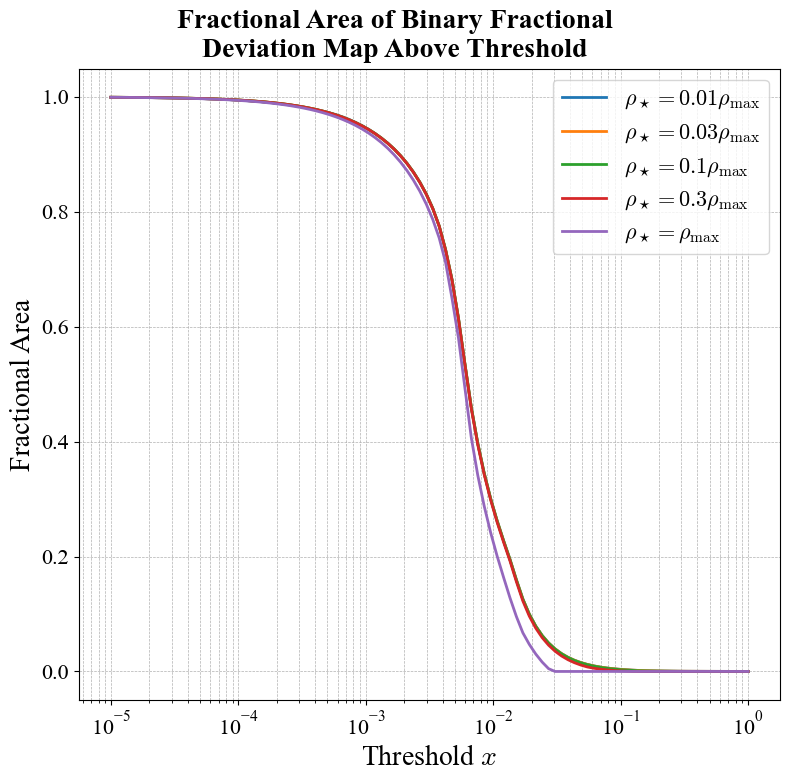

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Fractional Area of Binary Fractional\nDeviation Map Above Threshold', y=0.97)

ax.plot(thresholds, fractional_area_above_threshold[0], label=r'$\rho_\star = 0.01 \rho_\max$', linewidth=2)
ax.plot(thresholds, fractional_area_above_threshold[2], label=r'$\rho_\star = 0.03 \rho_\max$', linewidth=2)
ax.plot(thresholds, fractional_area_above_threshold[5], label=r'$\rho_\star = 0.1 \rho_\max$', linewidth=2)
ax.plot(thresholds, fractional_area_above_threshold[7], label=r'$\rho_\star = 0.3 \rho_\max$', linewidth=2)
ax.plot(thresholds, fractional_area_above_threshold[10], label=r'$\rho_\star = \rho_\max$', linewidth=2)

ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.set_xlabel(r'Threshold $x$')
ax.set_ylabel(r'Fractional Area')

ax.legend()

# fig.savefig('./Figures/Fractional Area of Binary Fractional Deviation Map Above Threshold.png', dpi=300)

plt.show()

In [439]:
np.argmin(np.abs(thresholds - 1e-2))

np.int64(59)

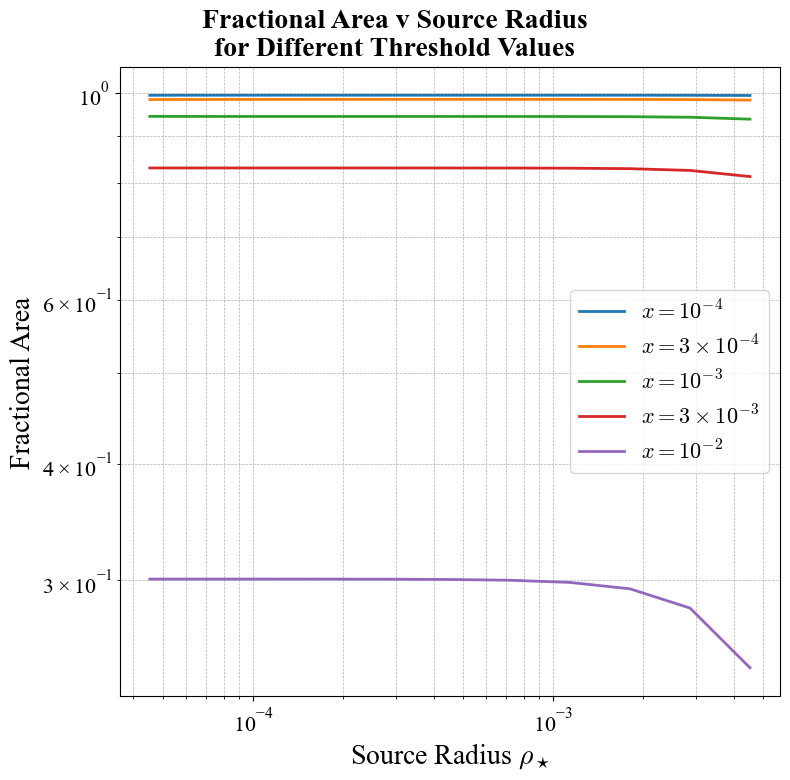

In [445]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Fractional Area v Source Radius\nfor Different Threshold Values', y=0.97)

ax.plot(source_radii, fractional_area_above_threshold[:, 20], label=r'$x = 10^{-4}$', linewidth=2)
ax.plot(source_radii, fractional_area_above_threshold[:, 29], label=r'$x = 3 \times 10^{-4}$', linewidth=2)
ax.plot(source_radii, fractional_area_above_threshold[:, 40], label=r'$x = 10^{-3}$', linewidth=2)
ax.plot(source_radii, fractional_area_above_threshold[:, 49], label=r'$x = 3 \times 10^{-3}$', linewidth=2)
ax.plot(source_radii, fractional_area_above_threshold[:, 59], label=r'$x = 10^{-2}$', linewidth=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.set_xlabel(r'Source Radius $\rho_\star$')
ax.set_ylabel(r'Fractional Area')

ax.legend()

fig.savefig('./Figures/Fractional Area v Source Radius for Different Threshold Values.png', dpi=300)

plt.show()

In [490]:
multipliers = [1e-1, 3e-1, 1e0, 3e0, 1e1]

df_list = []
thresholds_list = []
radius_list = []

one_e_4_list = []
three_e_4_list = []
one_e_3_list = []
three_e_3_list = []
one_e_2_list = []

for multiplier in multipliers:
    df = pd.read_csv(f'../Part 2/Data Files/analysis_output_{multiplier:.0e}.csv')
    df_list.append(df)

    thresholds = np.array(df.columns[4:], dtype=float)
    thresholds_list.append(thresholds)

    radius = np.array(df['source_radius'].to_list())
    radius_list.append(radius)

    one_e_4 = np.array(df['1.1e-04'].to_list())
    one_e_4_list.append(one_e_4)

    three_e_4 = np.array(df['3.4e-04'].to_list())
    three_e_4_list.append(three_e_4)

    one_e_3 = np.array(df['1.0e-03'].to_list())
    one_e_3_list.append(one_e_3)

    three_e_3 = np.array(df['3.1e-03'].to_list())
    three_e_3_list.append(three_e_3)

    one_e_2 = np.array(df['1.1e-02'].to_list())
    one_e_2_list.append(one_e_2)

ss_str_1 = np.array(df_list[0]['s'].to_list(), dtype=str)
ss_1 = np.array([numexpr.evaluate(str(s)) for s in df_list[0]['s'].to_list()])
qs_1 = np.array(df_list[0]['q'].to_list())

ss_str_unique_1 = np.array(['0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0', '1/0.9', '1/0.8', '1/0.7', '1/0.6', '1/0.5', '1/0.4', '1/0.3', '1/0.2'], dtype=str)
ss_unique_1 = np.array([numexpr.evaluate(s) for s in ss_str_unique_1], dtype=float)
qs_unique_1 = np.unique(qs_1)

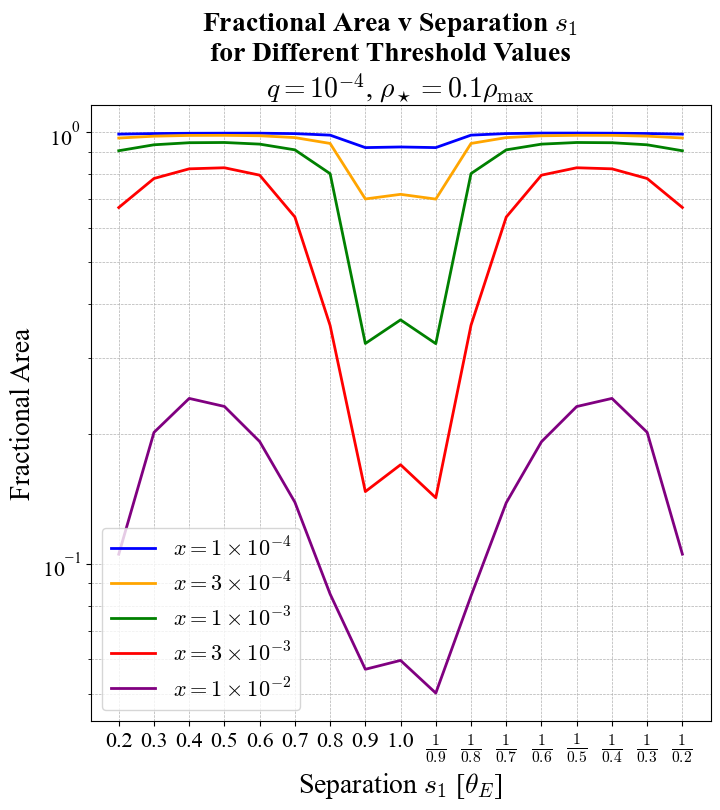

In [491]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Fractional Area v Separation $s_1$\nfor Different Threshold Values', y=1.0)

ax.set_title(r'$q = 10^{-4}$, $\rho_\star = 0.1 \rho_\max$')

df_subset = df_list[0][df_list[0]['q'] == 1e-04]

ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-04'], label='$x = 1 \\times 10^{-4}$', color='blue', linewidth=2)
ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.4e-04'], label='$x = 3 \\times 10^{-4}$', color='orange', linewidth=2)
ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.0e-03'], label='$x = 1 \\times 10^{-3}$', color='green', linewidth=2)
ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.1e-03'], label='$x = 3 \\times 10^{-3}$', color='red', linewidth=2)
ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-02'], label='$x = 1 \\times 10^{-2}$', color='purple', linewidth=2)

ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xticks(np.linspace(0, 1, len(df_subset)))

ax.set_xlabel('Separation $s_1$ [$\\theta_E$]')
ax.set_ylabel('Fractional Area')

ax.legend()

# Using stacked fractions for the x-ticks to show separation values instead of indices
ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_1])

# fig.savefig('./Figures/Fractional Area v Separation for Different Threshold Values.png', dpi=300)

plt.show()

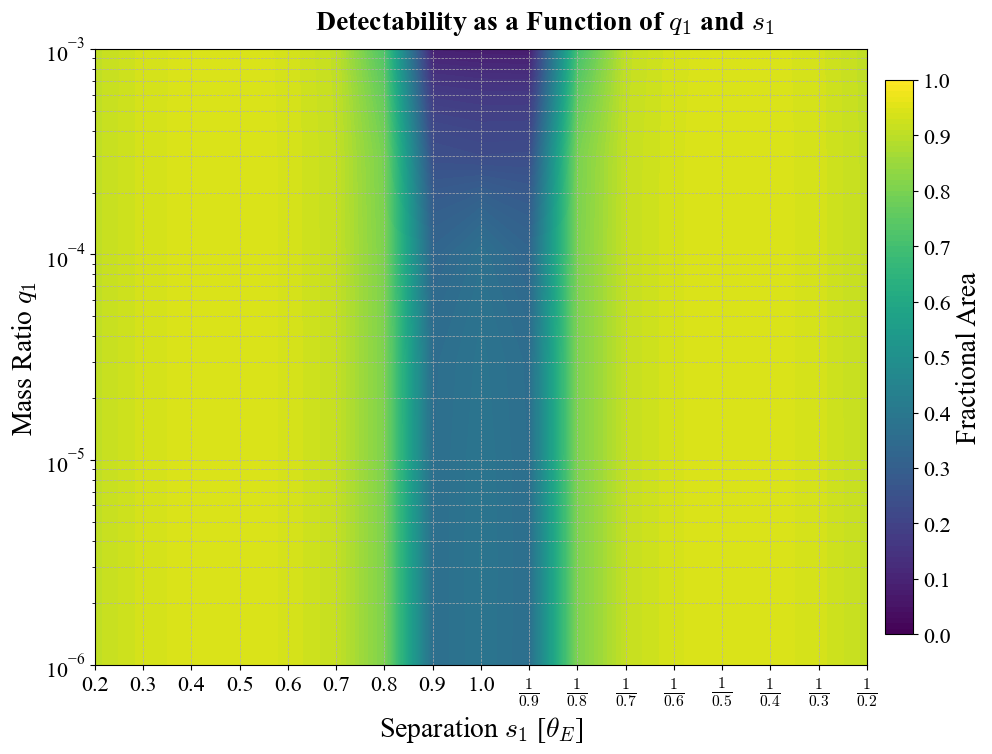

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot()

fig.suptitle('Detectability as a Function of $q_1$ and $s_1$', y=0.93)

df_subset = df_list[2]

plot = ax.contourf(
    np.linspace(0, 1, 17),
    qs_unique_1,
    np.array(df_subset['1.0e-03']).reshape((7, 17)),
    levels=np.linspace(0, 1, 101),
    cmap='viridis'
)

bar = plt.colorbar(plot, shrink=0.9, pad=0.02)
bar.set_label('Fractional Area')
bar.set_ticks(np.linspace(0, 1, 11))

# ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xticks(np.linspace(0, 1, 17))
# ax.set_xticklabels(ss_str_unique_1)
ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_1])

ax.set_xlabel('Separation $s_1$ [$\\theta_E$]')
ax.set_ylabel('Mass Ratio $q_1$')

# fig.savefig('./Figures/Detectability as a Function of q1 and s1.png', dpi=300)

plt.show()